# 1D Linear Poisson-Boltzmann Benchmark

This notebook validates the **linearized** Poisson-Boltzmann (PB) model in 1D.

## Model
For a symmetric electrolyte, the linear PB equation is:

$$
\frac{d^2 \phi}{dx^2} = \kappa^2 \phi
$$

where $\phi$ is electric potential and $\kappa^{-1}$ is the Debye length.

## Assumptions
- Small-potential regime: $|z e \phi / (k_B T)| \ll 1$
- Dilute electrolyte and continuum mean-field description
- 1D geometry for benchmark comparison
- Fixed boundary conditions set in the input cells

> Use this notebook when you want a fast, near-equilibrium reference solution.

## What to check in results
- Potential decays approximately exponentially away from charged boundaries
- Numerical profile is smooth and monotonic under standard conditions
- Parameter changes mainly rescale decay length and potential magnitude

In [1]:
import unxt
import quaxed.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
from fdm_edl.edl import ElectricalDoubleLayer
from fdm_edl import _constants

In [3]:
# 0.01 M 1-1 electrolyte, T = 298 K, epsilon_r = 78.5
edl_obj = ElectricalDoubleLayer("input.json")

In [4]:
beta = 1.0 / (_constants.BOLTZMANN_CONSTANT * edl_obj.temperature).to("eV")
# print((_constants.ELEMENTARY_CHARGE * unxt.Q(0.001, "V")).to("eV") * beta)

In [5]:
x = unxt.Quantity(jnp.linspace(0, 50.0, 500), unit="nm")

exp_factor = jnp.exp(-(x / edl_obj.electrolyte.debye_length)).to("")
sigma = _constants.ELEMENTARY_CHARGE / unxt.Quantity(1e4, "angstrom^2")

phi = (
    sigma * edl_obj.electrolyte.debye_length / edl_obj.electrolyte.epsilon * exp_factor
)

_rho = -sigma / edl_obj.electrolyte.debye_length * exp_factor
rho = (_rho / (_constants.ELEMENTARY_CHARGE * _constants.AVOGADRO_NUMBER)).to("mol/L")

In [6]:
def boltzmann_factor(phi, valancy: int = 1):
    return jnp.exp((-_constants.ELEMENTARY_CHARGE * phi * beta * valancy).to(""))

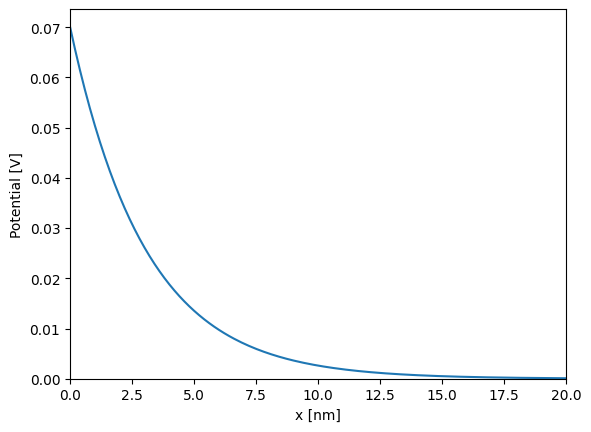

In [15]:
fig, ax = plt.subplots()

ax.plot(x.to("nm"), phi.to("V"))

ax.set_xlim(0, 20)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Potential [V]")

plt.show()

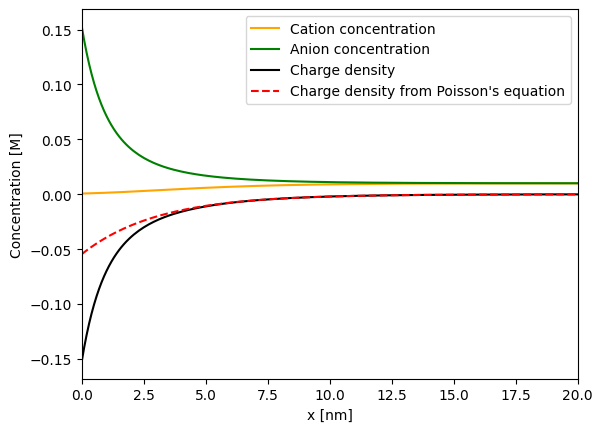

In [21]:
fig, ax = plt.subplots()

c_cation = edl_obj.electrolyte.ions[0].molar_conc * boltzmann_factor(phi, valancy=1)
c_anion = edl_obj.electrolyte.ions[1].molar_conc * boltzmann_factor(phi, valancy=-1)

ax.plot(x.to("nm"), c_cation, color="orange", label="Cation concentration")
ax.plot(x.to("nm"), c_anion, color="green", label="Anion concentration")
ax.plot(x.to("nm"), c_cation - c_anion, color="k", label="Charge density")

ax.plot(
    x.to("nm"), rho, "--", color="red", label="Charge density from Poisson's equation"
)

ax.set_xlim(0, 20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Concentration [M]")
ax.legend()

plt.show()